# Colorado Freight Flow Analysis, 2018–2024
## 02 — Analyze: Charts & Findings

**Input:** `co_freight_tidy_2018_2024.csv` (output of notebook 01)
**Question:** What's driving the decline in Colorado's freight tonnage? An analysis of commodity and mode shifts, 2018–2024.

Five charts, one per sub-question from the Ask phase. Each chart cell is followed by a
markdown cell where you write the finding in your own words (TODO markers).
All charts export as PNGs to `charts/` for the portfolio page and report.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

# ---- Portfolio palette (matches jakechervitz.github.io deck aesthetic) ----
NAVY   = '#1F3A5F'
CORAL  = '#E86A5E'
CREAM  = '#FAF3E7'
SAGE   = '#9CAF88'
INK    = '#2B2B2B'
GREY   = '#B9B4A8'

MODE_COLORS = {
    'Truck': NAVY,
    'Pipeline': CORAL,
    'Rail': SAGE,
    'Multiple modes & mail': GREY,
    'Air (incl. truck-air)': '#D9A441',
}

plt.rcParams.update({
    'figure.facecolor': CREAM,
    'axes.facecolor': CREAM,
    'axes.edgecolor': INK,
    'axes.labelcolor': INK,
    'text.color': INK,
    'xtick.color': INK,
    'ytick.color': INK,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.dpi': 110,
})

CHART_DIR = Path('charts')
CHART_DIR.mkdir(exist_ok=True)

tidy = pd.read_csv('co_freight_tidy_2018_2024.csv')
print(f"{len(tidy):,} rows | years {tidy.year.min()}–{tidy.year.max()}")
tidy.head(3)

60,200 rows | years 2018–2024


,origin,dms_dest,mode,commodity,sctg2,energy_group,year,ktons,value_m2017usd
0,Denver-Aurora CO,81,Truck,Live animals/fish,1,All other freight,2018,0.001710,0.009992
1,Denver-Aurora CO,89,Truck,Live animals/fish,1,All other freight,2018,84.979975,496.629219
2,Denver-Aurora CO,209,Truck,Live animals/fish,1,All other freight,2018,8.373146,48.933289


---
## Chart 1 — Total Colorado outbound tonnage by mode
*Sub-question: How has tonnage trended by mode? Establishes the decline is concentrated
in pipeline and rail, not truck.*

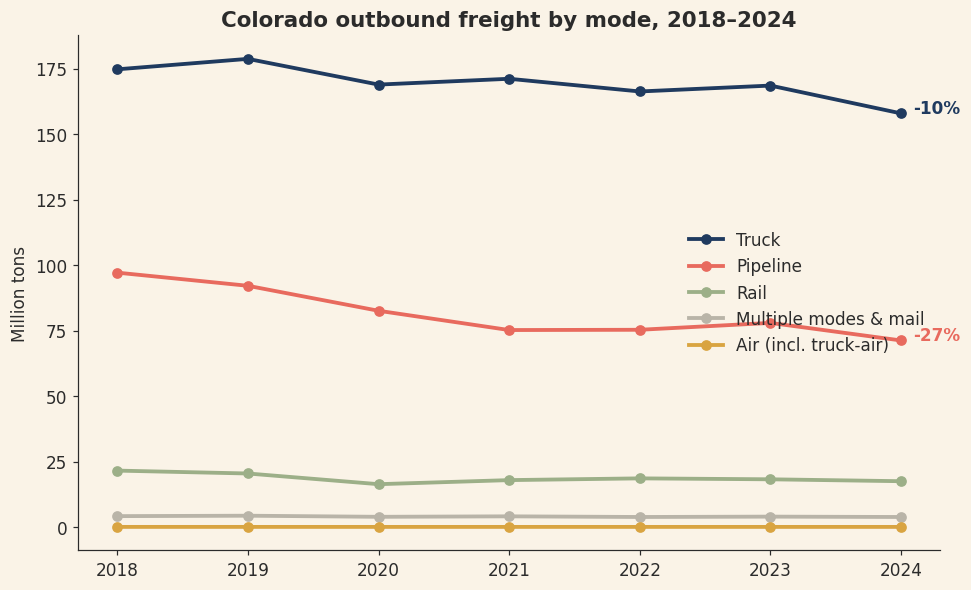

In [2]:
by_mode = (tidy.groupby(['mode', 'year'])['ktons'].sum()
           .div(1000)  # thousand tons -> million tons
           .unstack(level='mode'))

fig, ax = plt.subplots(figsize=(9, 5.5))
for mode in ['Truck', 'Pipeline', 'Rail', 'Multiple modes & mail', 'Air (incl. truck-air)']:
    ax.plot(by_mode.index, by_mode[mode], marker='o', lw=2.5,
            color=MODE_COLORS[mode], label=mode)

ax.set_title('Colorado outbound freight by mode, 2018–2024')
ax.set_ylabel('Million tons')
ax.set_xlabel('')
ax.legend(frameon=False, loc='center right')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# annotate the two headline changes
for mode in ['Truck', 'Pipeline']:
    chg = (by_mode[mode].loc[2024] / by_mode[mode].loc[2018] - 1) * 100
    ax.annotate(f'{chg:+.0f}%', xy=(2024, by_mode[mode].loc[2024]),
                xytext=(8, 0), textcoords='offset points',
                color=MODE_COLORS[mode], fontweight='bold')

plt.tight_layout()
plt.savefig(CHART_DIR / '01_mode_trends.png', bbox_inches='tight')
plt.show()

**Finding 1:**
Colorado's outbound freight tonnage fell 15.8% between 2018 and 2024, but the decline was far from evenly distributed. Pipeline volumes dropped 26.7% and rail fell 18.8%, while truck — which carries the majority of the state's tonnage — declined just 9.6%. The headline decline is concentrated in the two modes most tied to energy commodities, not in general freight demand.

---
## Chart 2 — The money chart: absolute tonnage change by commodity, 2018 → 2024
*Sub-question: Which commodities account for the decline? Energy commodities highlighted.*

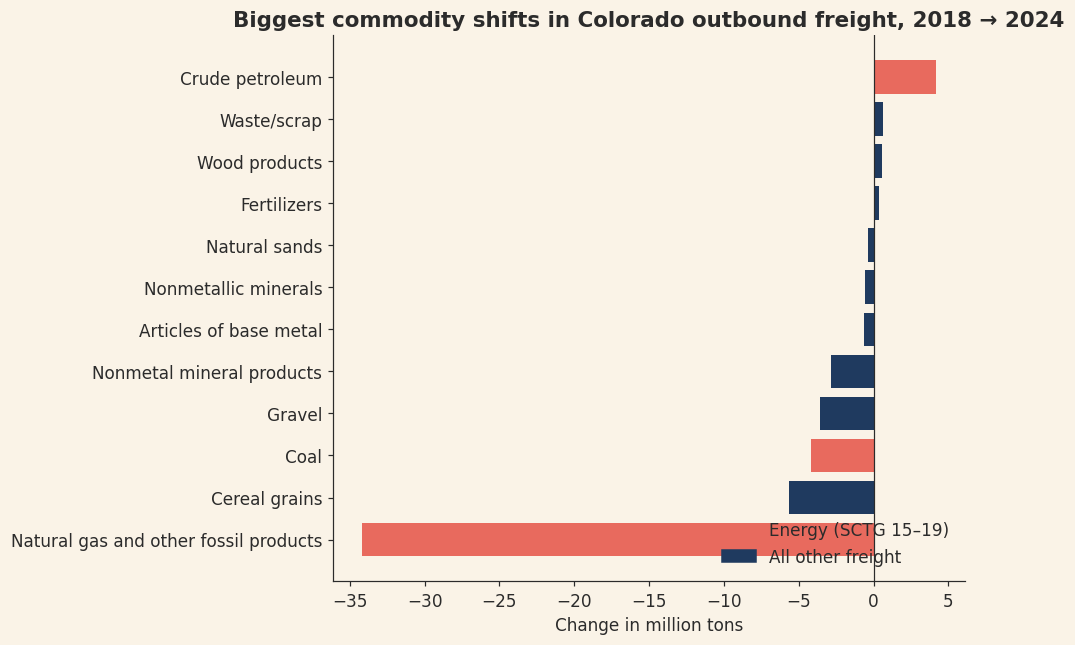

year                                   abs_chg
commodity                                     
Natural gas and other fossil products    -34.2
Cereal grains                             -5.6
Coal                                      -4.2
Gravel                                    -3.6
Nonmetal mineral products                 -2.8
Articles of base metal                    -0.7
Nonmetallic minerals                      -0.6
Natural sands                             -0.4
Fertilizers                                0.4
Wood products                              0.5
Waste/scrap                                0.6
Crude petroleum                            4.2


In [3]:
com = tidy.groupby(['commodity', 'energy_group'])['ktons'].sum()  # placeholder to get mapping
com_chg = (tidy.pivot_table(index='commodity', columns='year', values='ktons', aggfunc='sum')
           .assign(abs_chg=lambda d: (d[2024] - d[2018]) / 1000))  # million tons

energy_lookup = tidy.drop_duplicates('commodity').set_index('commodity')['energy_group']
com_chg['is_energy'] = energy_lookup.reindex(com_chg.index) == 'Energy (SCTG 15-19)'

movers = com_chg.reindex(com_chg['abs_chg'].abs().sort_values(ascending=False).head(12).index)
movers = movers.sort_values('abs_chg')

fig, ax = plt.subplots(figsize=(9, 6))
colors = [CORAL if e else NAVY for e in movers['is_energy']]
ax.barh(movers.index, movers['abs_chg'], color=colors)
ax.axvline(0, color=INK, lw=0.8)
ax.set_title('Biggest commodity shifts in Colorado outbound freight, 2018 → 2024')
ax.set_xlabel('Change in million tons')

# manual legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=CORAL, label='Energy (SCTG 15–19)'),
                   Patch(color=NAVY, label='All other freight')],
          frameon=False, loc='lower right')

plt.tight_layout()
plt.savefig(CHART_DIR / '02_commodity_change.png', bbox_inches='tight')
plt.show()

print(movers[['abs_chg']].round(1))

**Finding 2:**
A single commodity group explains most of the decline: natural gas and other fossil products (SCTG 19) fell 37.2%, a loss of 34.2 million tons — six times larger than the next biggest decline and more than every other declining commodity combined. Coal added a 22.2% drop of its own. The largest non-energy decline was cereal grains (-25.2%, -5.6 million tons), likely reflecting drought conditions and shifting agricultural patterns — causes outside this dataset's scope and flagged for follow-up analysis.

---
## Chart 3 — Energy vs. everything else (indexed, 2018 = 100)
*Sub-question: How do the two halves of Colorado's freight economy compare?*

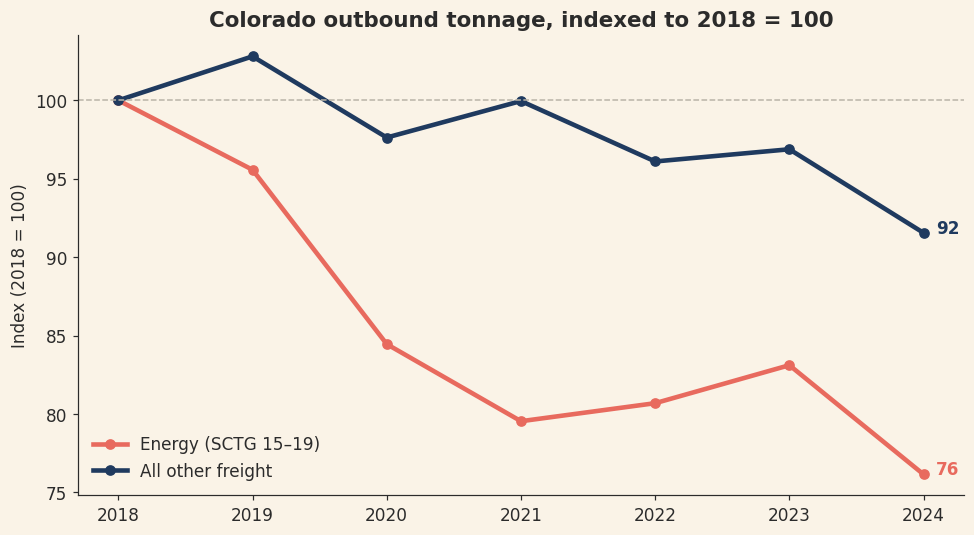

In [4]:
grp = (tidy.groupby(['energy_group', 'year'])['ktons'].sum().unstack(level=0))
indexed = grp / grp.loc[2018] * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(indexed.index, indexed['Energy (SCTG 15-19)'], marker='o', lw=3, color=CORAL,
        label='Energy (SCTG 15–19)')
ax.plot(indexed.index, indexed['All other freight'], marker='o', lw=3, color=NAVY,
        label='All other freight')
ax.axhline(100, color=GREY, lw=1, ls='--')
ax.set_title('Colorado outbound tonnage, indexed to 2018 = 100')
ax.set_ylabel('Index (2018 = 100)')
ax.legend(frameon=False)

for col, c in [('Energy (SCTG 15-19)', CORAL), ('All other freight', NAVY)]:
    ax.annotate(f"{indexed[col].loc[2024]:.0f}", xy=(2024, indexed[col].loc[2024]),
                xytext=(8, 0), textcoords='offset points', color=c, fontweight='bold')

plt.tight_layout()
plt.savefig(CHART_DIR / '03_energy_vs_other_indexed.png', bbox_inches='tight')
plt.show()

**Finding 3:**
Splitting Colorado's freight into energy commodities (SCTG 15–19) versus everything else reveals two different economies. By 2024, energy freight had fallen to an index of 76 (2018 = 100), while all other freight held at 92. Despite making up a minority of total volume, energy commodities drove 72% of the state's total tonnage decline. Colorado's freight contraction is largely an energy transition story, not a broad economic one.

---
## Chart 4 — Not a uniform fossil-fuel story: the five energy commodities individually
*Sub-question: Is it a blanket decline? (Spoiler: crude petroleum grew.)*

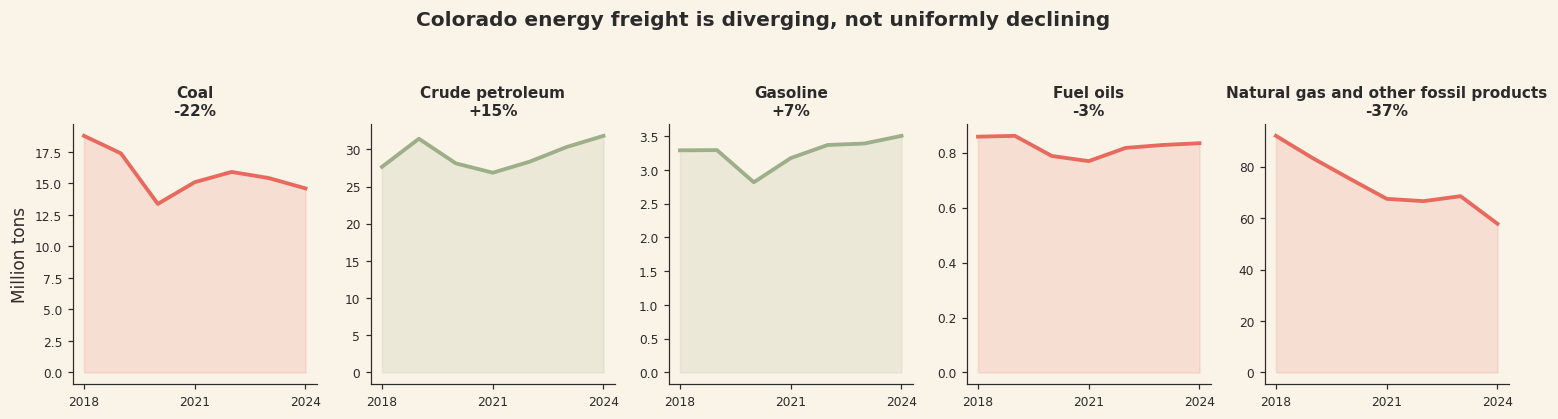

In [5]:
ENERGY = ['Coal', 'Crude petroleum', 'Gasoline', 'Fuel oils',
          'Natural gas and other fossil products']
en = (tidy[tidy['commodity'].isin(ENERGY)]
      .groupby(['commodity', 'year'])['ktons'].sum().div(1000).unstack(level=0))

fig, axes = plt.subplots(1, 5, figsize=(14, 3.6), sharex=True)
for ax, com in zip(axes, ENERGY):
    chg = (en[com].loc[2024] / en[com].loc[2018] - 1) * 100
    color = SAGE if chg > 0 else CORAL
    ax.plot(en.index, en[com], color=color, lw=2.5)
    ax.fill_between(en.index, en[com], alpha=0.15, color=color)
    ax.set_title(f"{com}\n{chg:+.0f}%", fontsize=10)
    ax.set_xticks([2018, 2021, 2024])
    ax.tick_params(labelsize=8)

axes[0].set_ylabel('Million tons')
fig.suptitle('Colorado energy freight is diverging, not uniformly declining', fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(CHART_DIR / '04_energy_small_multiples.png', bbox_inches='tight')
plt.show()

**Finding 4:**
The energy story itself has a split. Natural gas products (-37.2%) and coal (-22.2%) drive nearly all of the decline, consistent with Colorado's coal plant retirement schedule and reduced gas processing volumes. But crude petroleum freight moved the opposite direction, growing 15.1%.

A cross-check against EIA's Colorado Field Production of Crude Oil series complicates the obvious explanation: state crude production was roughly flat over 2018–2024 (~463 vs. ~465 thousand barrels/day annual average), peaking in 2019, bottoming in 2020–21, then recovering to near-2018 levels. Because the +15.1% freight growth outpaced essentially flat production, the increase likely reflects shipment-pattern changes — such as more crude moving out of state rather than to the two Denver-area refineries — and/or FAF modeling factors, not production growth alone.

Either way, carriers and infrastructure serving crude-related lanes face a fundamentally different demand outlook than assets exposed to coal and gas products.

---
## Chart 5 — The 'so what' chart: truck freight is the stable core
*Sub-question: What does this mean for the freight Colorado businesses actually touch?*

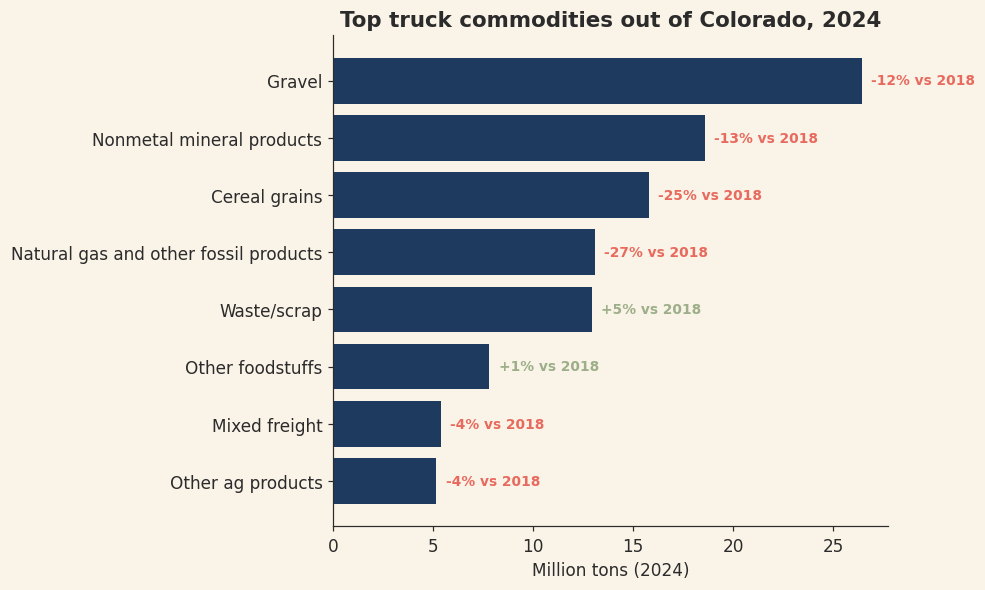

In [6]:
truck = tidy[tidy['mode'] == 'Truck']
truck_top = (truck.pivot_table(index='commodity', columns='year', values='ktons', aggfunc='sum')
             .div(1000)
             .assign(pct=lambda d: (d[2024] / d[2018] - 1) * 100)
             .sort_values(2024, ascending=False)
             .head(8)
             .sort_values(2024))

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(truck_top.index, truck_top[2024], color=NAVY)
for bar, (_, row) in zip(bars, truck_top.iterrows()):
    ax.annotate(f"{row['pct']:+.0f}% vs 2018",
                xy=(bar.get_width(), bar.get_y() + bar.get_height()/2),
                xytext=(6, 0), textcoords='offset points',
                va='center', fontsize=9,
                color=SAGE if row['pct'] > 0 else CORAL, fontweight='bold')

ax.set_title('Top truck commodities out of Colorado, 2024')
ax.set_xlabel('Million tons (2024)')
plt.tight_layout()
plt.savefig(CHART_DIR / '05_truck_stable_core.png', bbox_inches='tight')
plt.show()

**Finding 5:**
The commodities that dominate truck freight — gravel and aggregates, mixed freight, foodstuffs — remained comparatively stable through 2024, supporting metro construction and consumer distribution. For carriers and 3PLs operating in Colorado, the state's 15.8% headline tonnage decline overstates the risk to trucking demand: truck volumes fell just 9.6%, and the deeper shrinkage is happening in pipelines and rail cars, not on trucks.

---
## Key stats block (for the executive summary)

Run this cell and paste the numbers into your report.

In [7]:
stats = {}
tot = tidy.groupby('year')['ktons'].sum()
stats['Total decline 2018-2024'] = f"{(tot[2024]/tot[2018]-1)*100:.1f}%"

for m in ['Truck', 'Pipeline', 'Rail']:
    s = tidy[tidy['mode']==m].groupby('year')['ktons'].sum()
    stats[f'{m} change'] = f"{(s[2024]/s[2018]-1)*100:.1f}%"

for c in ['Natural gas and other fossil products', 'Coal', 'Crude petroleum', 'Cereal grains']:
    s = tidy[tidy['commodity']==c].groupby('year')['ktons'].sum()
    stats[f'{c}'] = f"{(s[2024]/s[2018]-1)*100:.1f}%"

eg = tidy.groupby(['energy_group','year'])['ktons'].sum().unstack(0)
share_of_decline = (eg['Energy (SCTG 15-19)'][2018]-eg['Energy (SCTG 15-19)'][2024]) / (tot[2018]-tot[2024]) * 100
stats['Energy share of total decline'] = f"{share_of_decline:.0f}%"

for k, v in stats.items():
    print(f"{k:45s} {v}")

Total decline 2018-2024                       -15.8%
Truck change                                  -9.6%
Pipeline change                               -26.7%
Rail change                                   -18.8%
Natural gas and other fossil products         -37.2%
Coal                                          -22.2%
Crude petroleum                               15.1%
Cereal grains                                 -25.2%
Energy share of total decline                 72%


---
## Recommendations:
1. Reassess energy-linked exposure. Revenue tied to coal rail lanes and natural gas product pipelines faces structural, not cyclical, decline — 72% of the state's tonnage loss came from energy commodities, and contract and asset decisions should assume continued contraction.
   
2. Treat Colorado truckload demand as stable. Fleet and lane investment decisions shouldn't be spooked by headline state tonnage figures; core truck commodities declined only modestly (-9.6% overall).

3. Watch crude-related capacity as a selective growth pocket (+15.1% since 2018), while monitoring the FAF6 benchmark release (mid-2026) and revisions to preliminary 2024 estimates before making long-horizon commitments.